# Diabetes

mangler interessant intro...

In [211]:
# Importer pakker der skal bruges
%pip install -q numpy matplotlib scikit-learn lightgbm graphviz ipython scipy

# Data
import numpy as np
import scipy as scipy

# Plotting
import matplotlib.pyplot as plt

# Sklearn: et librabry med en masse funtioner vi bruger i Machine Learning
import sklearn as sklearn

# Graphviz - Pakke der kan visualisere decision trees
from IPython.display import SVG, display
from graphviz import Source

# LightGBM - pakke til at køre decision tree
import lightgbm as lgb
from lightgbm import early_stopping

Note: you may need to restart the kernel to use updated packages.


## Inspicer dataen

Først vil vi gerne undersøge hvilken data vi har med at gøre. 

In [212]:
data = np.genfromtxt('Diabetes_data.csv', delimiter=',', names=True, dtype=None, encoding=None)

variabler = data.dtype.names
input_variabler = [v for v in variabler if v != 'Diabetes']
input_data = np.column_stack([data[v] for v in input_variabler])
truth_data = data['Diabetes']

# Print first 5 rows with names
print(" | ".join(variabler))
for row in data[:5]:
    print(" | ".join(str(row[v]) for v in variabler))

Age | Resting_Heart_Rate | Weight | Mean_Blood_Sugar | Blood_Pressure | Cholesterol | Hours_of_Training | Height | Diabetes
42.45 | 103.74 | 63.93 | 100.45 | 114.11 | 185.15 | 2.22 | 176.85 | 0
32.93 | 68.41 | 113.54 | 112.68 | 112.7 | 183.69 | 1.52 | 170.94 | 1
44.72 | 77.45 | 78.43 | 88.13 | 117.72 | 189.86 | 2.43 | 180.67 | 0
57.85 | 90.21 | 72.67 | 109.95 | 125.17 | 199.21 | 4.11 | 174.4 | 0
31.49 | 67.31 | 53.94 | 91.8 | 106.58 | 174.38 | 1.43 | 170.07 | 0


# Decision Tree

Et decision tree er bygget op af lag og grene. Ved hver gren stiller den et spørgsmål, og bevæger sig ned i det næste lag baseret på om spørgsmålet er sandt eller falsk. Og ved at lære af en masse data, kan den finde ud af hvilke spørgsmål der er bedst at stille.

### Parameter
For et decision tree kan vi justede på hvor mange lag der skal være i vores træ, altså hvor mange lag af spørgsmål der må stilles. Vi kan justere på den parameter herunder

In [213]:
DT_N_lag = 2                # Hvor mange lag der er i træet

Her bygger og træner vi modellen og bruger Graphviz til at visualisere det.

Max dybde af træet: 2


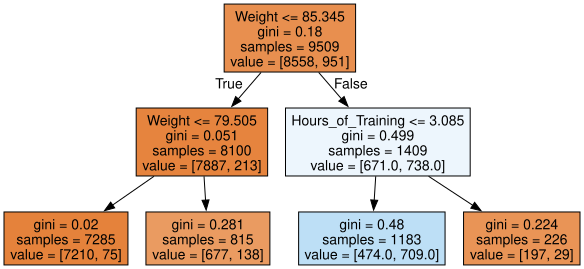

In [214]:
# Her bliver modellen trænet på data
estimator = sklearn.tree.DecisionTreeClassifier(max_depth=DT_N_lag, min_samples_leaf = 20,random_state=42)

estimator.fit(input_data, truth_data)   # Dette er den "magiske" linje - her optimerer Machine Learning algoritmen sine interne vægte til at give bedste svar

# laver visuel graf af træet
dot = sklearn.tree.export_graphviz(estimator, out_file=None, feature_names=input_variabler, filled=True, max_depth=50)         
dot = dot.replace("squared_error", "error").replace("mse", "error")
graph = Source(dot)
print("Max dybde af træet:", estimator.get_depth())
display(SVG(graph.pipe(format='svg')))


### Spørgsmål:

- Inspicer træet. Forstår du/I, hvad de forskellige tal betyder?
  Hvilken kasse falder de fleste personer ned I? hvor er der mindst? 
  
Tallene i value er [raske, diabetikere].
- Hvilke(n) af kasserne bliver kategoriseret som at have diabetes? 
- Hvor stor en del af patienter med diabetes vil den forudsige til at have diabetes?
- Prøv at ændre på hvor mange lag der er i træet fra 2 til 3.
  Hvilken parameter bliver brugt oftest til at opdele data? Tror du/I at den så er den vigtigste parameter?
  Kan du/I ud fra træet sige mere generelt hvilke parametre der betyder mest for om en person har diabetes? Hvilke betyder mindst?

## Boosted Decision Tree

Nu hvor vi har set hvordan træet virker, vil vi gerne prøve at forudsige værdien på huse som vi ikke kender salgsprisen på.
Som vi har set, kan det være svært at minimere vores 'loss function'. En måde at forbedre på er ved at køre boosted decision trees, hvilket vil sige at vi kører flere træer, hvor den hver gang lærer af fejlene fra det forrige træ, og på den måde bliver "boostet" for hvert træ den laver. Herunder kan vi ændre hvor mange gange den må "booste", altså hvor mange træer den må lave og lærer af.

In [215]:
boosting_rounds = 10        # Hvor mange runder af træer den må lave og lærer af

vi bruger train_test_split til at splitte data i et træningssæt og et testsæt.
træningssættet bruges til at træne modellen, hvor modellen får salgspriserne at vide.
testsættet bruges til at give den trænede model data uden salgspriser, som den så skal forudsige, men hvor vi stadig kender svaret

In [216]:
data_træning, data_test, sande_gruppe_træning, sande_gruppe_test = \
    sklearn.model_selection.train_test_split(input_data, truth_data, test_size=0.25, random_state=42)

In [217]:
# Her bygger vi modellen op med flere træer, træner på data og forudsiger priser

gbm_test = lgb.LGBMClassifier(objective='binary', n_estimators=boosting_rounds, verbosity=-1)

gbm_test.fit(data_træning, sande_gruppe_træning, eval_set=[(data_test, sande_gruppe_test)], 
             eval_metric='mse', callbacks=[early_stopping(15)])

forudsagte_gruppe = gbm_test.predict(data_test, num_iteration=gbm_test.best_iteration_)

forudsagte_score = gbm_test.predict_proba(data_test, num_iteration=gbm_test.best_iteration_)[:, 1]


Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[10]	valid_0's l2: 0.0375978	valid_0's binary_logloss: 0.147095


In [ ]:
# Denne function laver plots til at vise hvor godt klassifikations-algoritmen klarer sig.
def plotting(y_true, y_pred, y_score):
    """
    y_true  : array-like, sande klasser (0/1)
    y_pred  : array-like, forudsagte klasser (0/1)
    y_score : array-like, score/prob for positiv klasse (fx clf.predict_proba(X)[:,1])
    """

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    ###---- VENSTRE PLOT: CONFUSION MATRIX -----###
    ax = axes[0]
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
    disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion matrix')
    ax.set_xlabel('Forudsagt gruppe')
    ax.set_ylabel('Sande gruppe')

    ###---- HØJRE PLOT: ROC-KURVE -----###
    ax = axes[1]
    fpr, tpr, _ = sklearn.metrics.roc_curve(y_true, y_score)
    auc = sklearn.metrics.roc_auc_score(y_true, y_score)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], 'r--', label='Tilfældig')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC-kurve')
    ax.grid(True)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


Nu vil vi gerne inspicere hvor god vores model er til at forusige på data hvor den ikke kender prisen. Det venstre plot viser.... Det højre plot viser...



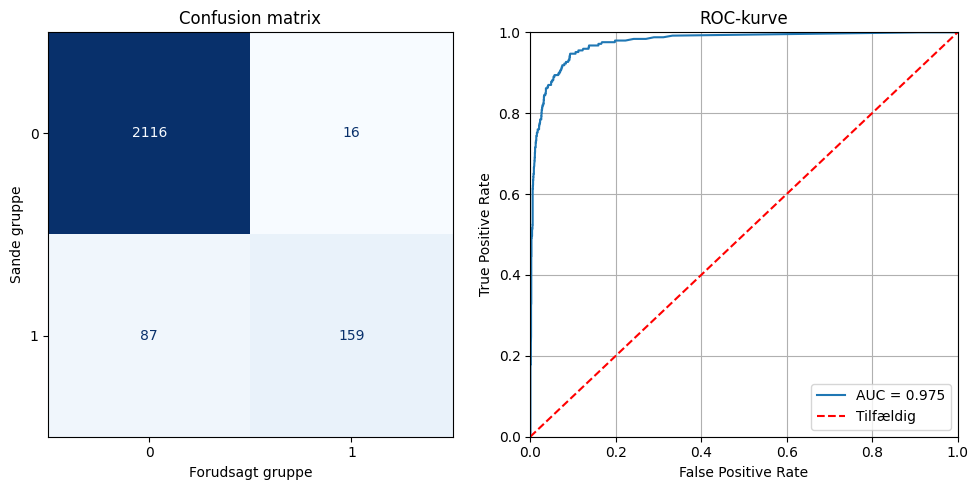

In [219]:
plotting(sande_gruppe_test, forudsagte_gruppe, forudsagte_score)

### Spørgsmål:

- Prøv at ændre på hvor mange gange gange den må booste, ved at ændre boosting_rounds fra 1 til 10, 100 eller 1000. Kan du se en forbedring?
- Hvor laver modellen flest fejl? Raske der grupperes som diabetikere, eller omvendt?

### Hvilke variabler er vigtigst?
Vi kan tjekke om vores intuition for hvilke variabler der er vigtigst med "permutation importance". Det er et mål for hvis værdierne i en kolonne bliver byttet rundt randomly, hvor meget påvirker det så resultatet. Hvis det er en vigtig variable, vil det påvirke resultatet meget. Her bliver det mål på hvor meget større mean squared error bliver, når den variabel bliver "scramblet".

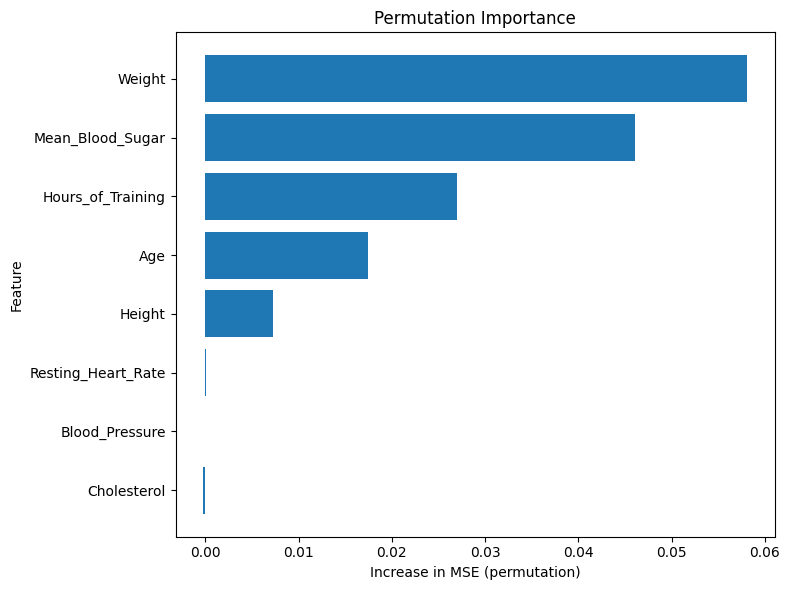

In [220]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")

res = sklearn.inspection.permutation_importance(gbm_test, data_test, sande_gruppe_test, scoring="neg_mean_squared_error")

imp_mse = res.importances_mean                
order = np.argsort(imp_mse)[::-1]
labels = np.asarray(variabler[:-1])[order]
vals = imp_mse[order]

plt.figure(figsize=(8, 6))
y = np.arange(len(vals))
plt.barh(y, vals)
plt.yticks(y, labels)
plt.xlabel("Increase in MSE (permutation)")
plt.ylabel("Feature")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

Er resultatet som du forventede?

# Neurale Netværk

Neurale Netværk (NN) kommer fra at opbygningen af det, minder om den måde vores neuroner i hjernen snakker sammen på. På samme måde som et decision tree er der forskellige lag og vi kan styre hvor mange lag der er, men nu er det ikke kun sandt eller falsk, i stedet fungerer noderne som knapper der kan fintunes. 

Neurale netværk er mere følsomme overfor det data vi giver dem. Den fungerer bedst hvis resultatet er værdier mellem 0 og 1. Derfor bruger vi en funktion til at skalere vores data, kaldet StandardScaler

In [221]:
scaler = sklearn.preprocessing.StandardScaler()

data_træning = scaler.fit_transform(data_træning)
data_test = scaler.transform(data_test)

I et neuralt netværk kan vi justere på hvor mange lag og hvor mange noder hvert lag skal have:

In [222]:
layer_one   = 64            # Her definerer vi hvor mange lag der skal være, og hvor mange 'neuroner' eller noder 
layer_two   = 32            # hvert lag skal have. Prøv at ændre på antal noder 
layer_three = 16            # for at forbedre din model
layer_four  = 8
layer_five  = 4
layer_six   = 2

Nedenfor træner vi modellen. Vi kan også regne ud hvor mange parameter modellen bruger.
Herefter plotter vi for at se hvor godt modellen klarer sig.

Antal parametre i NN: 3369


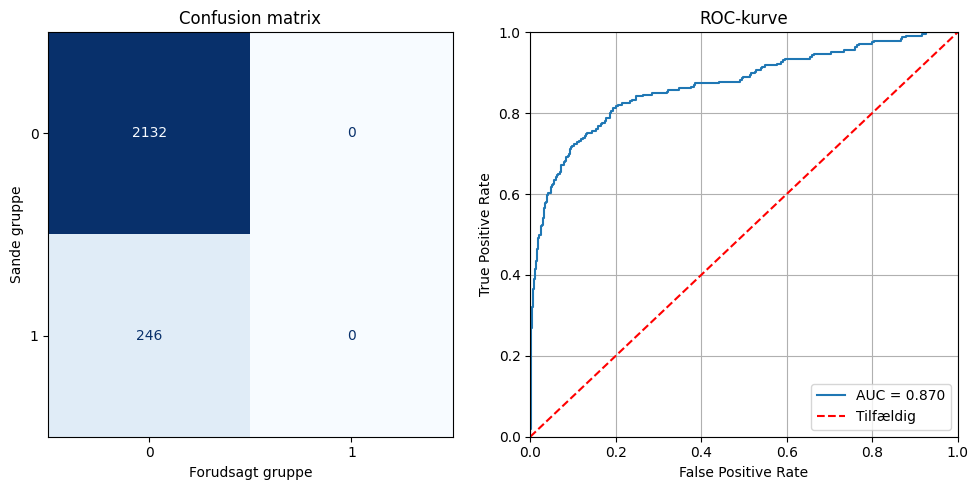

In [223]:
# Her definerer og træner vi modellen
mlp = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(layer_one, layer_two, layer_three, layer_four, layer_five, layer_six), 
max_iter=2000, early_stopping=True, random_state=42)
mlp.fit(data_træning, sande_gruppe_træning) 

# Her giver vi den trænede model test data som den ikke har set før, og beder om at forudsige prisen
forudsagte_gruppe = mlp.predict(data_test)  
forudsagte_score = mlp.predict_proba(data_test)[:, 1]

# Beregn antal parametre i modellen
# Coef er vægtene er intercept er bias. Den henter antallet directe fra modellen.
n_params = sum(coef.size + intercept.size for coef, intercept in zip(mlp.coefs_, mlp.intercepts_))
print(f"Antal parametre i NN: {n_params}")

plotting(sande_gruppe_test, forudsagte_gruppe, forudsagte_score)

### Spørsgmål:
- Prøv at justere på antal neuroner i det neurale netværk - Kan du mindske usikkerheden?
- Får du det samme antal parameter når du regner efter?
- Hvilken algoritme klarer sig bedst? Boosted decision tree eller neutralt netværk?
- Prøv at justere på dit BDT og NN så de rammer samme AUC. Hvilken algoritme er så hurtigts?